In [16]:
import sys
print(sys.executable)

/Users/mac/Desktop/test v2/venv/bin/python


In [17]:
!which pip

/Users/mac/Desktop/test v2/venv/bin/pip


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_json('/Users/mac/Desktop/test v2/data/bronze/avito_raw_20260502_104741.json')



In [2]:
print(df.shape)

(31, 13)


In [3]:
df.columns

Index(['titre', 'prix', 'prix_type', 'ville', 'quartier', 'surface',
       'nb_chambres', 'nb_salles_bain', 'etage', 'annee_construction', 'lien',
       'scraped_at', 'error'],
      dtype='str')

In [4]:
print(df.head())

                                               titre      prix prix_type  \
0                   À Emile Zola appart vide à louer  4 500 DH   mensuel   
1  Ensoleillé, 0 vis à vis, 1er étage avec ascenseur  3 490 DH   mensuel   
2                Appartement à louer 100 m² à Temara  6 000 DH   mensuel   
3            Appartements à louer 61 m² à Casablanca  4 000 DH   mensuel   
4              Appartement à louer 50 m² à Marrakech  6 000 DH   mensuel   

        ville      quartier surface nb_chambres nb_salles_bain etage  \
0  Casablanca  Sidi Maarouf      75           2              1     4   
1   Marrakech      Mabrouka      53           2              1     1   
2      Temara         Wifak     100           3              2     3   
3  Casablanca        Nassim      61           2              1     1   
4   Marrakech        Guéliz      50           1              1     5   

  annee_construction                                               lien  \
0                     https://www.a

In [5]:
print(df.dtypes)

titre                            str
prix                             str
prix_type                        str
ville                            str
quartier                         str
surface                          str
nb_chambres                      str
nb_salles_bain                   str
etage                            str
annee_construction               str
lien                             str
scraped_at            datetime64[us]
error                        float64
dtype: object


In [6]:
missing_ratio = df.isna().mean() * 100
print("\nMissing Values (%):\n", missing_ratio.sort_values(ascending=False))


Missing Values (%):
 error                 100.0
prix                    0.0
prix_type               0.0
ville                   0.0
titre                   0.0
quartier                0.0
surface                 0.0
nb_salles_bain          0.0
nb_chambres             0.0
etage                   0.0
annee_construction      0.0
lien                    0.0
scraped_at              0.0
dtype: float64


In [19]:
df['prix'] = (
    df['prix']
    .str.replace(r'\D', '', regex=True)
    .astype('Int64')
)

In [20]:
df['prix_type'].dtype
df['prix_type'].value_counts()

prix_type
mensuel    31
Name: count, dtype: int64

In [21]:
df['prix_type'] = (
    df['prix_type']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [22]:
df['prix'].head()

0    4500
1    3490
2    6000
3    4000
4    6000
Name: prix, dtype: Int64

In [23]:
df['prix_type'] = pd.Categorical(
    df['prix_type'],
    categories=['journalier', 'mensuel', 'inconnu'],
    ordered=True
)

In [24]:
cols = ['surface', 'nb_chambres', 'nb_salles_bain', 'etage', 'annee_construction']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

In [25]:
df['nb_salles_bain'].dtypes
df['nb_salles_bain'].head()

0    1
1    1
2    2
3    1
4    1
Name: nb_salles_bain, dtype: Int64

In [27]:
df['nb_salles_bain'] = df['nb_salles_bain'].fillna(df['nb_salles_bain'].median())

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   titre               31 non-null     str           
 1   prix                31 non-null     Int64         
 2   prix_type           31 non-null     category      
 3   ville               31 non-null     str           
 4   quartier            31 non-null     str           
 5   surface             29 non-null     Int64         
 6   nb_chambres         28 non-null     Int64         
 7   nb_salles_bain      31 non-null     Int64         
 8   etage               28 non-null     Int64         
 9   annee_construction  0 non-null      Int64         
 10  lien                31 non-null     str           
 11  scraped_at          31 non-null     datetime64[us]
 12  error               0 non-null      float64       
dtypes: Int64(6), category(1), datetime64[us](1), float64(1), str(4)

In [7]:
missing_ratio = df.isna().mean() * 100
print("\nMissing Values (%):\n", missing_ratio.sort_values(ascending=False))


Missing Values (%):
 error                 100.0
prix                    0.0
prix_type               0.0
ville                   0.0
titre                   0.0
quartier                0.0
surface                 0.0
nb_salles_bain          0.0
nb_chambres             0.0
etage                   0.0
annee_construction      0.0
lien                    0.0
scraped_at              0.0
dtype: float64


In [26]:
df['nb_salles_bain'].skew()

np.float64(2.0963308341496436)

In [29]:
df['nb_chambres'].skew()

np.float64(1.8206798341381163)

In [30]:
df['nb_chambres'] = df['nb_chambres'].fillna(df['nb_chambres'].median())

In [31]:
df['etage'].skew()

np.float64(1.162819719990739)

In [32]:
df['etage'] = df['etage'].fillna(df['etage'].mode()[0])

In [33]:
df['surface'].skew()

np.float64(3.5144146426658742)

In [34]:
df['surface'] = df['surface'].fillna(df['surface'].median())

In [35]:
duplicates = df.duplicated(subset='lien').sum()
print("\nDuplicate lien:", duplicates)


Duplicate lien: 0


In [36]:
df['prix'].head()

0    4500
1    3490
2    6000
3    4000
4    6000
Name: prix, dtype: Int64

In [37]:
df['surface'] = pd.to_numeric(df['surface'], errors='coerce')
df['nb_chambres'] = pd.to_numeric(df['nb_chambres'], errors='coerce')

In [38]:
print(df.dtypes)

titre                            str
prix                           Int64
prix_type                   category
ville                            str
quartier                         str
surface                        Int64
nb_chambres                    Int64
nb_salles_bain                 Int64
etage                          Int64
annee_construction             Int64
lien                             str
scraped_at            datetime64[us]
error                        float64
dtype: object


In [39]:
df['ville'].value_counts()

ville
Casablanca             17
Marrakech               5
Bouskoura               2
Rabat                   2
Temara                  1
Fès                     1
Mohammedia              1
Tanger                  1
COURS ET FORMATIONS     1
Name: count, dtype: int64

COURS ET FORMATION ?     'COURS ET FORMATIONS' is a scraper artefact — not a real city.

In [40]:
df = df[df['ville'] != 'COURS ET FORMATIONS']

In [41]:
df['quartier'].value_counts().head(10)

quartier
Maarif                   3
Quartier des Hôpitaux    3
Sidi Maarouf             2
Guéliz                   2
Agdal                    2
Gauthier                 2
Mabrouka                 1
Wifak                    1
Nassim                   1
Ain Sebaa                1
Name: count, dtype: int64

In [42]:
df['prix'].describe()

count            30.0
mean     20124.666667
std      40632.081917
min            3490.0
25%            6000.0
50%            8000.0
75%            9975.0
max          200000.0
Name: prix, dtype: Float64

In [43]:
df[['prix', 'surface']].corr()

,prix,surface
prix,1.000000,0.703049
surface,0.703049,1.000000


In [44]:
df.sort_values(by='prix', ascending=False).head()

,titre,prix,prix_type,ville,quartier,surface,nb_chambres,nb_salles_bain,etage,annee_construction,lien,scraped_at,error
10,Immeuble à usage professionnel à louer,200000,mensuel,Rabat,Agdal,1200,8,1,4,<NA>,https://www.avito.ma/fr/agdal/bureaux/Immeuble...,2026-05-02 10:40:24.228444,NaN
30,IMMEUBLE PROFESSIONNEL À LOUER À GAUTIER,120000,mensuel,Casablanca,Gauthier,75,2,1,1,<NA>,https://www.avito.ma/fr/gauthier/autre_immobil...,2026-05-02 10:47:23.324980,NaN
6,VILLA EXCLUSIVE HAUT STANDING – FRONT GOLF,57000,mensuel,Bouskoura,Ville verte,1311,5,5,3,<NA>,https://www.avito.ma/fr/ville_verte/villas_et_...,2026-05-02 10:38:16.050831,NaN
8,Bureau 130 m² à louer Agdal-Rabat,20000,mensuel,Rabat,Agdal,130,4,2,4,<NA>,https://www.avito.ma/fr/agdal/bureaux/Bureau_1...,2026-05-02 10:39:34.039525,NaN
13,Location Local de 134 m2 à Bouskoura,18000,mensuel,Bouskoura,Bouskoura centre,134,2,1,1,<NA>,https://www.avito.ma/fr/bouskoura_centre/local...,2026-05-02 10:41:38.997013,NaN


In [45]:
print(df.head())

                                               titre  prix prix_type  \
0                   À Emile Zola appart vide à louer  4500   mensuel   
1  Ensoleillé, 0 vis à vis, 1er étage avec ascenseur  3490   mensuel   
2                Appartement à louer 100 m² à Temara  6000   mensuel   
3            Appartements à louer 61 m² à Casablanca  4000   mensuel   
4              Appartement à louer 50 m² à Marrakech  6000   mensuel   

        ville      quartier  surface  nb_chambres  nb_salles_bain  etage  \
0  Casablanca  Sidi Maarouf       75            2               1      4   
1   Marrakech      Mabrouka       53            2               1      1   
2      Temara         Wifak      100            3               2      3   
3  Casablanca        Nassim       61            2               1      1   
4   Marrakech        Guéliz       50            1               1      5   

   annee_construction                                               lien  \
0                <NA>  https://www

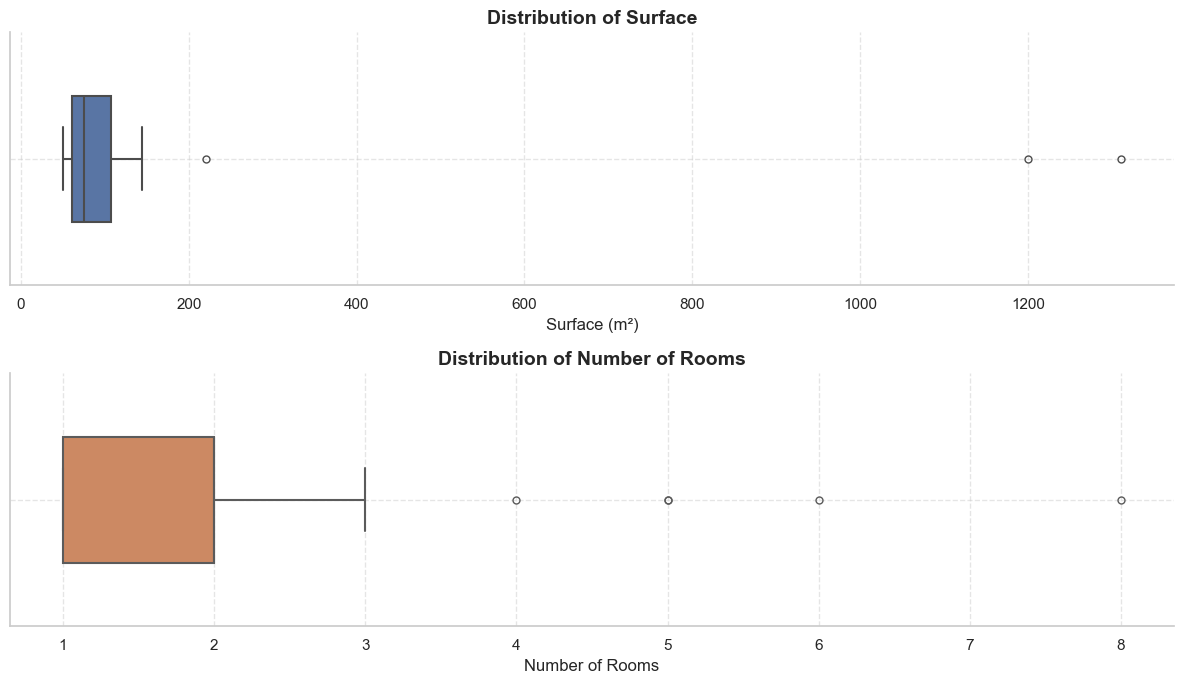

In [48]:
# Global style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# --- Surface ---
sns.boxplot(
    data=df,
    x='surface',
    ax=axes[0],
    color="#4C72B0",
    width=0.5,
    fliersize=5,
    linewidth=1.5
)

axes[0].set_title("Distribution of Surface", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Surface (m²)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# --- Chambres ---
sns.boxplot(
    data=df,
    x='nb_chambres',
    ax=axes[1],
    color="#DD8452",
    width=0.5,
    fliersize=5,
    linewidth=1.5
)

axes[1].set_title("Distribution of Number of Rooms", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Number of Rooms")
axes[1].grid(True, linestyle="--", alpha=0.5)

# Clean borders
for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

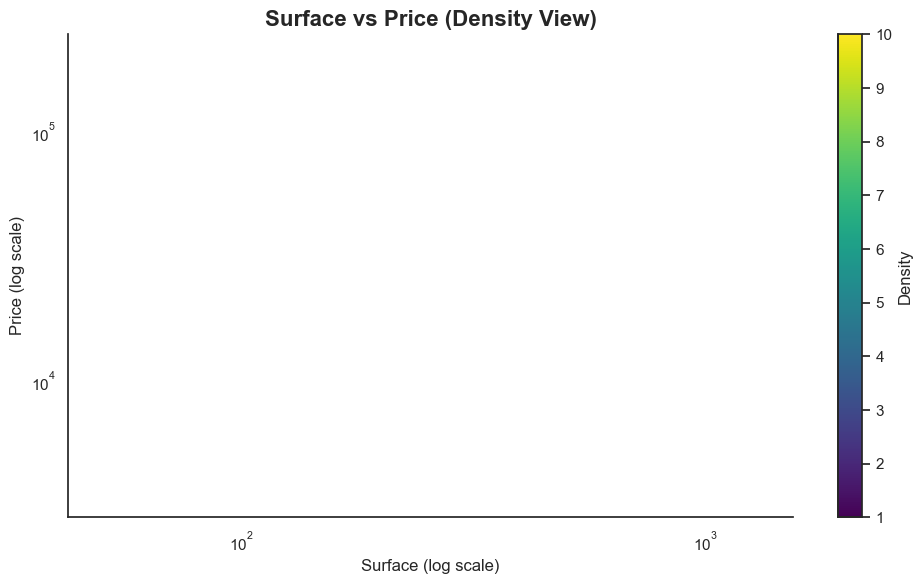

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clean data (important for log scale)
df_plot = df[['surface', 'prix']].dropna()
df_plot = df_plot[(df_plot['surface'] > 0) & (df_plot['prix'] > 0)]

# Style
sns.set_theme(style="white")

plt.figure(figsize=(10, 6))

hb = plt.hexbin(
    df_plot['surface'],
    df_plot['prix'],
    gridsize=40,
    cmap='viridis',
    mincnt=1
)

plt.colorbar(hb, label='Density')

# Log scale
plt.xscale('log')
plt.yscale('log')

plt.title("Surface vs Price (Density View)", fontsize=16, fontweight='bold')
plt.xlabel("Surface (log scale)")
plt.ylabel("Price (log scale)")

sns.despine()
plt.tight_layout()
plt.show()